In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Bidirectional, LSTM,
    Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns

# ── STEP 1: Load Data ──

In [10]:
data   = pd.read_csv('/kaggle/input/datasets/salmanthecodepro/catalyst-gene-bilstm-attention-for-cancer/data.csv',   index_col=0)
labels = pd.read_csv('/kaggle/input/datasets/salmanthecodepro/gene-expression-cancer-rna-seq-levels/labels.csv', index_col=0)

print(f"Data shape: {data.shape}")
print(f"Cancer types: {labels['Class'].value_counts()}")

Data shape: (801, 20531)
Cancer types: Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


# ── STEP 2: Preprocessing ──

In [11]:
# Variance-based feature selection (top 1000 genes)

gene_var = data.var(axis=0)
top_genes = gene_var.nlargest(1000).index
X = data[top_genes].values
y_raw = labels['Class'].values

# Label encode

le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f"Classes: {le.classes_}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Normalize

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

Classes: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']
X shape: (801, 1000), y shape: (801,)


# ── STEP 3: Feature Engineering ──

In [12]:
X_df = pd.DataFrame(X)

# Gene expression statistics as extra features

X_df['mean_expr']   = X_df.mean(axis=1)
X_df['std_expr']    = X_df.std(axis=1)
X_df['max_expr']    = X_df.max(axis=1)
X_df['min_expr']    = X_df.min(axis=1)
X_df['range_expr']  = X_df['max_expr'] - X_df['min_expr']
X = X_df.values
print(f"After feature engineering: {X.shape}")

After feature engineering: (801, 1005)


# ── STEP 4: Split ──

In [13]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

# Reshape for LSTM: (samples, timesteps=1, features)

X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val   = X_val.reshape(X_val.shape[0],   1, X_val.shape[1])
X_test  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

n_classes   = len(le.classes_)
input_shape = (1, X_train.shape[2])
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Classes: {n_classes}")

Train: (512, 1, 1005), Val: (128, 1, 1005), Test: (161, 1, 1005)
Classes: 5


# ── STEP 5: Attention Layer ──

In [17]:
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
    def build(self, input_shape):
        self.W = Dense(self.units)
        self.V = Dense(1)
        super().build(input_shape)
    def call(self, inputs):
        score             = tf.nn.tanh(self.W(inputs))
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        context_vector    = tf.reduce_sum(attention_weights * inputs, axis=1)
        return context_vector, attention_weights
    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

attn = BahdanauAttention(units=64)
print("Ready:", attn.units)

Ready: 64


# ── STEP 6: Baseline Model ──

In [19]:
def build_baseline_model(input_shape, n_classes):
    inputs = Input(shape=input_shape)
    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = LSTM(64, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = LSTM(32)(x)
    x = Dropout(0.2)(x)
    x = Dense(16, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(n_classes, activation='softmax')(x)
    return Model(inputs, outputs)

baseline_model = build_baseline_model(input_shape, n_classes)
baseline_model.summary()

2026-05-02 15:00:59.263859: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 1005)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 1, 256)         │     1,161,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 64)          │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,257,701 (4.80 MB)

 Trainable params: 1,257,061 (4.80 MB)

 Non-trainable params: 640 (2.50 KB)

# ── STEP 7: CATALYST-Gene Model ──

In [20]:
def build_catalyst_gene(input_shape, n_classes):
    inputs = Input(shape=input_shape)

    # BiLSTM
    x = Bidirectional(LSTM(128, return_sequences=True))(inputs)
    x = BatchNormalization()(x); x = Dropout(0.2)(x)

    # Attention
    context, attn_weights = BahdanauAttention(units=64)(x)

    # LSTM branch
    x2 = LSTM(64, return_sequences=True)(x)
    x2 = BatchNormalization()(x2); x2 = Dropout(0.2)(x2)
    x3 = LSTM(32)(x2); x3 = Dropout(0.2)(x3)

    # Combine
    combined = tf.keras.layers.Concatenate()([context, x3])
    x_out = Dense(64, activation='relu')(combined); x_out = Dropout(0.3)(x_out)
    x_out = Dense(32, activation='relu')(x_out);   x_out = Dropout(0.2)(x_out)
    outputs = Dense(n_classes, activation='softmax')(x_out)
    return Model(inputs=inputs, outputs=outputs)

baseline_model = build_baseline_model(input_shape, n_classes)
catalyst_model  = build_catalyst_gene(input_shape, n_classes)
print("Models ready!")


Models ready!


# ── STEP 8: Train ──

In [21]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

for model in [baseline_model, catalyst_model]:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

print("Training Baseline...")
history_baseline = baseline_model.fit(
    X_train, y_train, epochs=100, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks, verbose=1
)

print("\nTraining CATALYST-Gene...")
history_catalyst = catalyst_model.fit(
    X_train, y_train, epochs=100, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks, verbose=1
)


Training Baseline...
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.5710 - loss: 1.4000 - val_accuracy: 0.9922 - val_loss: 1.5224 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9132 - loss: 0.9074 - val_accuracy: 0.9688 - val_loss: 1.3838 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9773 - loss: 0.6474 - val_accuracy: 0.9922 - val_loss: 1.2000 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9813 - loss: 0.4565 - val_accuracy: 1.0000 - val_loss: 1.0117 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9912 - loss: 0.3142 - val_accuracy: 1.0000 - val_loss: 0.8189 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9857 - loss: 0.2363 - val_accuracy: 1.0000 - val_loss: 0.6397 - learning_rate: 0.0010
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9

# ── STEP 9: Evaluate ──

In [22]:
base_pred  = np.argmax(baseline_model.predict(X_test), axis=1)
cat_pred   = np.argmax(catalyst_model.predict(X_test),  axis=1)

print("\n=== RESULTS ===")
print(f"{'Metric':<12} {'Baseline':>10} {'CATALYST':>10}")
print("-" * 35)
print(f"{'Accuracy':<12} {accuracy_score(y_test, base_pred):>10.4f} {accuracy_score(y_test, cat_pred):>10.4f}")

print("\nCATALYST Classification Report:")
print(classification_report(y_test, cat_pred, target_names=le.classes_))


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step

=== RESULTS ===
Metric         Baseline   CATALYST
-----------------------------------
Accuracy         1.0000     1.0000

CATALYST Classification Report:
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



# ── STEP 10: Visualization ──

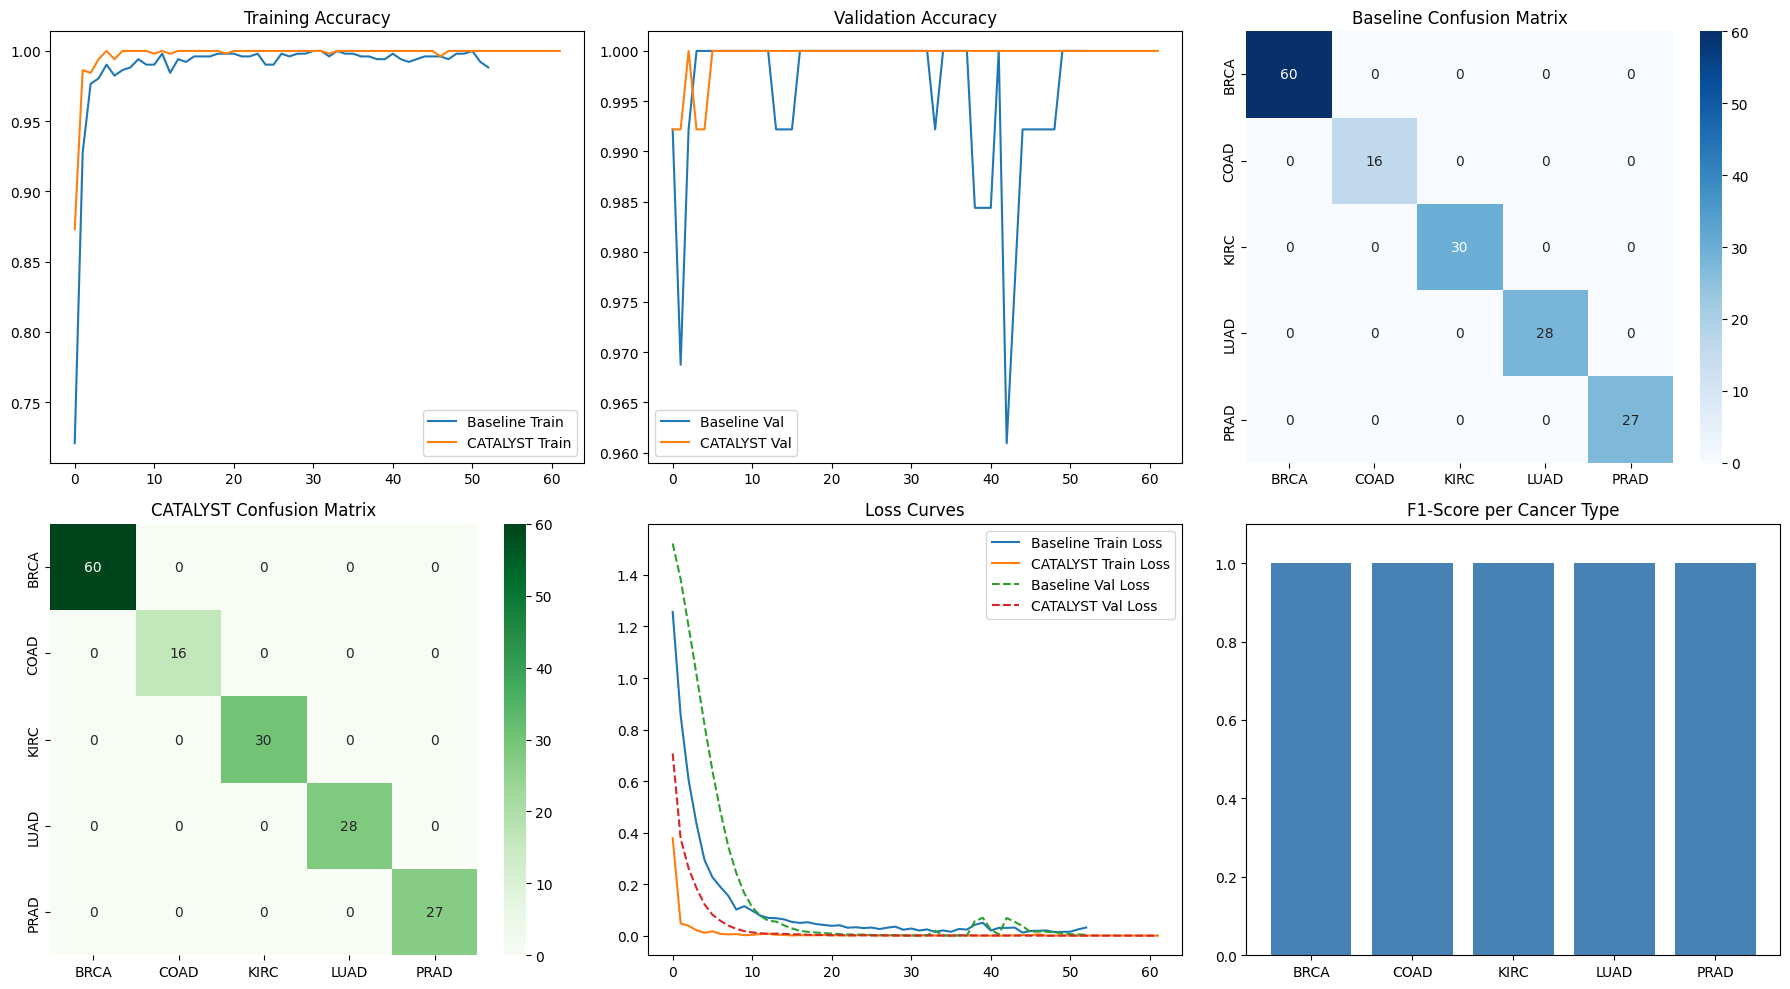

Done!


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Training curves
axes[0,0].plot(history_baseline.history['accuracy'], label='Baseline Train')
axes[0,0].plot(history_catalyst.history['accuracy'],  label='CATALYST Train')
axes[0,0].set_title('Training Accuracy'); axes[0,0].legend()

axes[0,1].plot(history_baseline.history['val_accuracy'], label='Baseline Val')
axes[0,1].plot(history_catalyst.history['val_accuracy'],  label='CATALYST Val')
axes[0,1].set_title('Validation Accuracy'); axes[0,1].legend()

# Confusion Matrices
sns.heatmap(confusion_matrix(y_test, base_pred), annot=True, fmt='d',
            ax=axes[0,2], cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[0,2].set_title('Baseline Confusion Matrix')

sns.heatmap(confusion_matrix(y_test, cat_pred), annot=True, fmt='d',
            ax=axes[1,0], cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1,0].set_title('CATALYST Confusion Matrix')

# Loss curves
axes[1,1].plot(history_baseline.history['loss'],     label='Baseline Train Loss')
axes[1,1].plot(history_catalyst.history['loss'],      label='CATALYST Train Loss')
axes[1,1].plot(history_baseline.history['val_loss'], label='Baseline Val Loss', linestyle='--')
axes[1,1].plot(history_catalyst.history['val_loss'],  label='CATALYST Val Loss', linestyle='--')
axes[1,1].set_title('Loss Curves'); axes[1,1].legend()

# Per-class accuracy
cat_report = classification_report(y_test, cat_pred,
    target_names=le.classes_, output_dict=True)
f1_scores = [cat_report[c]['f1-score'] for c in le.classes_]
axes[1,2].bar(le.classes_, f1_scores, color='steelblue')
axes[1,2].set_title('F1-Score per Cancer Type')
axes[1,2].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('catalyst_gene_results.png', dpi=300)
plt.show()
print("Done!")